# Data Sets from the Literature

The following data sets were obtained from the literature.


## Acid \& Base hydrolysis of benzyl chloride

Refer to problem \#8 of the handout. This notebook refers to the data presented in table&nbsp;4 of the class handout.

Data for the hydrolysis of benzyl chloride were obtained from..

"Relations Entre la Constitution du Substrat et sa Sensibilité à L'ion oh dans L'hydrolyse." S.C.J. Olivier, A.P. Weber, *Recl. Trav. Chim. Pays-Bas*, **1934**, *53*, 869-890. https://doi.org/10.1002/recl.19340531002

Rates of hydrolysis are reported for substituted benzyl chlorides in the following conditions.

1. 50% Acetone, in acidic conditions
2. 50% Acetone, 0.0506 M NaOH
3. 50% Acetone, 0.104 M NaOH
4. 50% Acetone, 0.259 M NaOH

All performed at $30 ^\circ C$

**Note:** 
- The acidic conditions were 0.052, 0.27 and 0.50 M H2SO4 and the rate constants were constant in value across that range.  
- The rate constants for acidic conditions are first-order in [BzCl] and are reported in units of /$10^{-5} min^{-1}$.
- The rate constants for basic conditions are first-order in [BzCl] and are reported in units of /$10^{-5} min^{-1}$ for each of the concentrations of hydroxide. These could be made into the second order rate constant by dividing by the concentration of hydroxide reactant in each series.

In [28]:
####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M12_Handout_Comments/data.zip
    !unzip -q data.zip

github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()

#################################################################
### Global Variable                                           ###
#################################################################

sigmatype = "sigma"          # sigmatype can be one of ["sigma", "s_plus", "s_minus"]

#################################################################
### a function to fill in sigma for empty spaces in s+ and s- ###
#################################################################

def fill_sigma(df):     
    for z in df.index:
        if np.isnan(df.loc[z,"s_plus"]):
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]
        if np.isnan(df["s_minus"][z]):
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]
    return(df)

##########################################################################
### a function to print out the statistical parameters from a line fit ###
##########################################################################


def Report(comment, result):
    print(comment)
    print(f"slope = {result.slope:-.3f} +/- {result.stderr:.3f}")
    print(f"intercept = {result.intercept:-.3f} +/- {result.intercept_stderr:.3f}")
    print(f"rsq = {(result.rvalue)**2:-.3}")
    print(f"p = {(result.pvalue):-.3}")
    print("")


print("Setup complete")


Setup complete


## Read Experimental Data

Read in a .csv file and make a DataFrame.

In [21]:
Data_Set = "data/Table_4_Data.csv"

################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

Filename = Data_Set

df1 = pd.read_csv(Filename,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 
display(df1)

,k_H2O,k_0.05,k_0.10,k_0.26
Substituent,,,,
H,2.20,17.0,31,61
p-CH3,19.00,38.0,58,94
o-CH3,9.40,42.0,68,127
m-CH3,2.60,33.2,28,53
p-Br,1.09,17.0,34,64
o-Br,0.58,11.0,22,47
m-Br,0.41,9.0,17,37
m-CN,0.27,17.0,33,68
p-CN,0.25,22.0,43,92


## Hammett Parameters from A. Williams
This table presents the Hammett $\sigma$ LFER values collected values presented in the collection curated by A. Williams in his book, “Free Energy Relationships in Organic and Bio-organic Chemistry”, *The Royal Society of Chemistry, Cambridge*, **2003**, pp 258-277. https://doi.org/10.1039/9781847550927.

 The data series are as follows:
 
- **Substituent**
     - The code of the substituent and the **index series**. Hopefully we will use a unique code for each substituent that will apply across all these data tables. Students should use data cleaning methods to track down duplicate data and mismatched codes.
- **sigma**
    - The Hammett $\sigma$ value
- **s_plus**
    - The Brown-Okamoto $\sigma_p^+$ value
- **s_minus**
    - The Brown-Okamoto $\sigma_p^-$ value
- **Page**
    - The page number in book. This is included to enable faster checking of the data by other students (all errors are intentional - to see if they are paying attention.)
    
**Note:** You may also use the Hansch data set available from the GitHub page.

### Cleaning Data Set

the code below will extract and clean the data from the database for use in  this analysis.

In [22]:
################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

LFER_Data = "LFER_HanschLeoTaft.csv"   # Choose which set of Hammett parameters you prefer
#LFER_Data = "LFER_Williams.csv"

Filename = github_location_LFER_tables + LFER_Data

df2 = pd.read_csv(Filename, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 
#display(df)

########################################################
### Fill across sigma values and select substituents ###
########################################################

df2 = fill_sigma(df2)
#display(df2)

###############################
### Remove unneeded columns ###
###############################
 
df2.drop(labels = ["TABLE V", "TABLE I"],    #Trim "LFER_HanschLeoTaft.csv" data
#df2.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
        axis = 1,
        inplace = True)
#print(df2)
#df2.sort_values(by=['sigma'], inplace=True)
display(df2.head())

,sigma,s_plus,s_minus,sigma_I,sigma_n,sigma_star,F,R,R+,R-
Substituent,,,,,,,,,,
m-Br,0.39,0.39,0.39,NaN,NaN,NaN,NaN,0.00,0.0,0.0
p-Br,0.23,0.15,0.25,0.47,0.23,1.000,0.45,-0.22,-0.3,-0.2
m-C6H5,0.06,0.06,0.06,NaN,NaN,NaN,NaN,0.00,0.0,0.0
p-C6H5,-0.01,0.02,-0.18,0.12,NaN,0.215,0.12,-0.13,-0.3,-0.1
m-CCCH3,0.21,0.21,0.21,NaN,NaN,NaN,NaN,0.00,0.0,0.0


## Combine Data Sets

Both data sets are indexed by "Substituent". The code below will combine the two data sets according to "Substituent" and take the intersection of the sets.

In [23]:
df = pd.concat([df2, df1], axis=1, join="inner")
display(df.head(3))

,sigma,s_plus,s_minus,sigma_I,sigma_n,sigma_star,F,R,R+,R-,k_H2O,k_0.05,k_0.10,k_0.26
Substituent,,,,,,,,,,,,,,
m-Br,0.39,0.39,0.39,NaN,NaN,NaN,NaN,0.00,0.0,0.0,0.41,9.0,17,37
p-Br,0.23,0.15,0.25,0.47,0.23,1.0,0.45,-0.22,-0.3,-0.2,1.09,17.0,34,64
m-CH3,-0.07,-0.07,-0.07,NaN,NaN,NaN,NaN,0.00,0.0,0.0,2.60,33.2,28,53


## Calculations

The rates are reported in units of $10^{-5} min^{-1}$.  They will be converted to $min^{-1}$ by multiplying the values by $10^{-5}$. Then the log values will be calculated for the log-log Hammett plots.

See the code below.

In [24]:

df["k_H2O"] = df["k_H2O"]*(10**(-5))
df["k_0.05"] = df["k_0.05"]*(10**(-5))
df["k_0.10"] = df["k_0.10"]*(10**(-5))
df["k_0.26"] = df["k_0.26"]*(10**(-5))
df["log_k_H2O"] = np.log10(df["k_H2O"])
df["log_k_0.05"] = np.log10(df["k_0.05"])
df["log_k_0.10"] = np.log10(df["k_0.10"])
df["log_k_0.26"] = np.log10(df["k_0.26"])
display(df.head(3))

#df.drop(labels = ["p-CH3"], axis = 0, inplace = True)

,sigma,s_plus,s_minus,sigma_I,sigma_n,sigma_star,F,R,R+,R-,k_H2O,k_0.05,k_0.10,k_0.26,log_k_H2O,log_k_0.05,log_k_0.10,log_k_0.26
Substituent,,,,,,,,,,,,,,,,,,
m-Br,0.39,0.39,0.39,NaN,NaN,NaN,NaN,0.00,0.0,0.0,0.000004,0.000090,0.00017,0.00037,-5.387216,-4.045757,-3.769551,-3.431798
p-Br,0.23,0.15,0.25,0.47,0.23,1.0,0.45,-0.22,-0.3,-0.2,0.000011,0.000170,0.00034,0.00064,-4.962574,-3.769551,-3.468521,-3.193820
m-CH3,-0.07,-0.07,-0.07,NaN,NaN,NaN,NaN,0.00,0.0,0.0,0.000026,0.000332,0.00028,0.00053,-4.585027,-3.478862,-3.552842,-3.275724


Basic hydrolysis
slope = 0.002 +/- 0.194
intercept = -3.193 +/- 0.073
rsq = 1.33e-05
p = 0.994

Acidic solvolysis
slope = -1.965 +/- 0.322
intercept = -4.477 +/- 0.121
rsq = 0.882
p = 0.00171



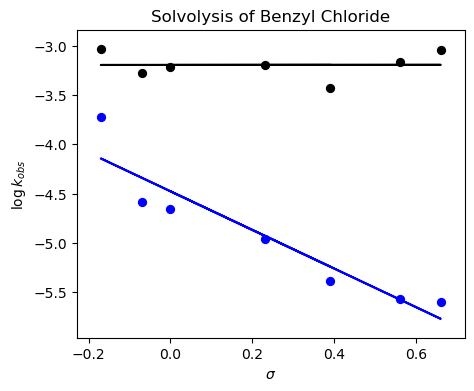

In [36]:
sigmatype = "sigma"       # sigmatype can be one of ["sigma", "s_plus", "s_minus"]

#####################################################################
### Create plot and set up some styling 
#####################################################################

plt.rcdefaults()          # reset the plot parameters to the default values, in case they were changed by a previous plot

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  # create a new figure and axis
ax.margins(x=.07, y=.07, tight=True)                     # set the margins of the plot to 7% of the data range in both x and y directions

if sigmatype == "s_plus":      # set the x-axis label based on the sigma type selected above
    x_label = r"$\sigma^+$"
elif sigmatype == "s_minus":
    x_label = r"$\sigma^-$"
elif sigmatype == "sigma":
    x_label = r"$\sigma$"
else:
    x_label = "ERROR"

ax.set(                        # set the plot labels and limits
          title="Solvolysis of Benzyl Chloride",       
          ylabel=r"$\log{k_{obs}}$", 
          xlabel=x_label,                
#          xlim=[-.9,.9],                  
#          ylim=[-3.7,-2.7]
    )

#####################################################################
### Plot the data for one of the alkaline hydrolysis experiments  ###
#####################################################################

x = df[sigmatype]    # use the sigma type selected above to choose which column of data to plot
y = df["log_k_0.26"] # use the log of the rate constant for the 26% NaOH experiment
                     # can chhose any of the other three alkaline hydrolysis experiments 
                     #   by changing the column name to "log_k_0.05", "log_k_0.10", or "log_k_0.26"

linfit = linregress(x,y)            # perform a linear regression on the data to get the slope, intercept, and correlation coefficient
fity = linfit.slope * x + linfit.intercept

ax.plot(x, fity, color='black', zorder=1, label="26% NaOH")  # plot the line fit to the data
ax.scatter(x,y, s=32, color="black", zorder=3)

Report("Basic hydrolysis", linfit)  # print out the slope, intercept, and correlation coefficient for the line fit

#################################################################
### Plot the data for one of the acid hydrolysis experiments  ###
#################################################################

x = df[sigmatype]
y = df["log_k_H2O"]

linfit = linregress(x,y)
fity = linfit.slope * x + linfit.intercept

ax.plot(x, fity, color='blue', zorder=1, label="acid hydrolysis")  # plot the line fit to the data
ax.scatter(x,y, s=32, color="blue", marker='o', zorder=3)

Report("Acidic solvolysis", linfit)

plt.show()
fig.savefig("plots/plot4.pdf") 

